In [1]:
# Cell 1: Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    ConfusionMatrixDisplay
)

In [2]:
# Cell 2: Load Dataset from Raw GitHub Link

url = "https://raw.githubusercontent.com/sunairakhan/Decision-Tree-Comparison/main/data.csv"

df = pd.read_csv(url)

df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [3]:
# Cell 3: Check Dataset Information

print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nMissing Values:")
print(df.isnull().sum())

df.head()

Dataset Shape: (569, 33)

Column Names:
Index(['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst', 'Unnamed: 32'],
      dtype='object')

Missing Values:
id                           0
diagnosis                    0
radius_mean                  0
texture_mean                 0
perimeter_mean               0
area_mean                    0
smoothness_mean              0
compactness_mean             0
concavity_mean               0

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [4]:
# Cell 4: Data Preprocessing

# Remove unnecessary columns if they exist
if "id" in df.columns:
    df = df.drop("id", axis=1)

if "Unnamed: 32" in df.columns:
    df = df.drop("Unnamed: 32", axis=1)

# Handle missing values
df = df.dropna()

# Encode target column
# M = Malignant, B = Benign
label_encoder = LabelEncoder()
df["diagnosis"] = label_encoder.fit_transform(df["diagnosis"])

print("After preprocessing:")
print(df.head())

print("\nClass labels:")
print(label_encoder.classes_)

After preprocessing:
   diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0          1        17.99         10.38          122.80     1001.0   
1          1        20.57         17.77          132.90     1326.0   
2          1        19.69         21.25          130.00     1203.0   
3          1        11.42         20.38           77.58      386.1   
4          1        20.29         14.34          135.10     1297.0   

   smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
0          0.11840           0.27760          0.3001              0.14710   
1          0.08474           0.07864          0.0869              0.07017   
2          0.10960           0.15990          0.1974              0.12790   
3          0.14250           0.28390          0.2414              0.10520   
4          0.10030           0.13280          0.1980              0.10430   

   symmetry_mean  ...  radius_worst  texture_worst  perimeter_worst  \
0         0.2419  ...   

In [5]:
# Cell 5: Select Features and Target

X = df[["radius_mean", "texture_mean"]]
y = df["diagnosis"]

print("Selected Features:")
print(X.head())

print("\nTarget:")
print(y.head())

Selected Features:
   radius_mean  texture_mean
0        17.99         10.38
1        20.57         17.77
2        19.69         21.25
3        11.42         20.38
4        20.29         14.34

Target:
0    1
1    1
2    1
3    1
4    1
Name: diagnosis, dtype: int64


In [6]:
# Cell 6: Train-Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

Training data shape: (455, 2)
Testing data shape: (114, 2)


In [7]:
# Cell 7: CART Model Using Gini + Cross-Validation

cart_model = DecisionTreeClassifier(
    criterion="gini",
    random_state=42
)

param_grid = {
    "max_depth": [2, 3, 4, 5, 6, None],
    "min_samples_split": [2, 5, 10]
}

cart_grid = GridSearchCV(
    estimator=cart_model,
    param_grid=param_grid,
    cv=5,
    scoring="accuracy"
)

cart_grid.fit(X_train, y_train)

best_cart = cart_grid.best_estimator_

print("Best CART Parameters:")
print(cart_grid.best_params_)

print("\nBest CART Cross-Validation Accuracy:")
print(cart_grid.best_score_)

Best CART Parameters:
{'max_depth': 2, 'min_samples_split': 2}

Best CART Cross-Validation Accuracy:
0.8901098901098902


In [8]:
# Cell 8: ID3 Model Using Entropy + Cross-Validation

id3_model = DecisionTreeClassifier(
    criterion="entropy",
    random_state=42
)

id3_grid = GridSearchCV(
    estimator=id3_model,
    param_grid=param_grid,
    cv=5,
    scoring="accuracy"
)

id3_grid.fit(X_train, y_train)

best_id3 = id3_grid.best_estimator_

print("Best ID3 Parameters:")
print(id3_grid.best_params_)

print("\nBest ID3 Cross-Validation Accuracy:")
print(id3_grid.best_score_)

Best ID3 Parameters:
{'max_depth': 2, 'min_samples_split': 2}

Best ID3 Cross-Validation Accuracy:
0.887912087912088


In [9]:
# Cell 9: Test Set Predictions

cart_pred = best_cart.predict(X_test)
id3_pred = best_id3.predict(X_test)

cart_prob = best_cart.predict_proba(X_test)[:, 1]
id3_prob = best_id3.predict_proba(X_test)[:, 1]

print("CART Predictions:")
print(cart_pred[:10])

print("\nID3 Predictions:")
print(id3_pred[:10])

CART Predictions:
[0 1 1 0 0 0 0 0 0 0]

ID3 Predictions:
[0 1 1 0 0 0 0 0 0 0]


In [10]:
# Cell 10: Evaluation Metrics

cart_metrics = {
    "Accuracy": accuracy_score(y_test, cart_pred),
    "Precision": precision_score(y_test, cart_pred),
    "Recall": recall_score(y_test, cart_pred),
    "F1 Score": f1_score(y_test, cart_pred),
    "AUC": roc_auc_score(y_test, cart_prob)
}

id3_metrics = {
    "Accuracy": accuracy_score(y_test, id3_pred),
    "Precision": precision_score(y_test, id3_pred),
    "Recall": recall_score(y_test, id3_pred),
    "F1 Score": f1_score(y_test, id3_pred),
    "AUC": roc_auc_score(y_test, id3_prob)
}

metrics_df = pd.DataFrame({
    "CART (Gini)": cart_metrics,
    "ID3 (Entropy)": id3_metrics
})

metrics_df

,CART (Gini),ID3 (Entropy)
Accuracy,0.859649,0.859649
Precision,0.933333,0.933333
Recall,0.666667,0.666667
F1 Score,0.777778,0.777778
AUC,0.926587,0.926587


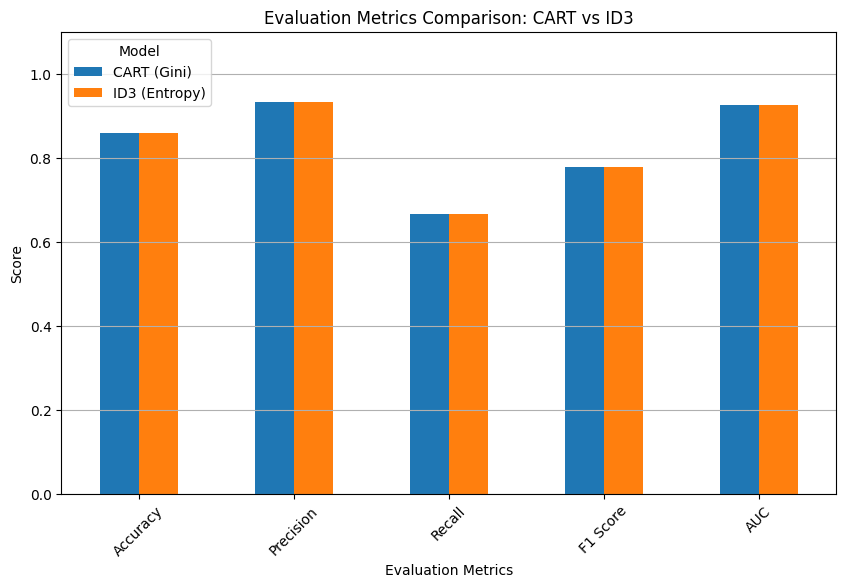

In [11]:
# Cell 11: Evaluation Metrics Bar Chart

metrics_df.plot(kind="bar", figsize=(10, 6))

plt.title("Evaluation Metrics Comparison: CART vs ID3")
plt.xlabel("Evaluation Metrics")
plt.ylabel("Score")
plt.ylim(0, 1.1)
plt.xticks(rotation=45)
plt.grid(axis="y")
plt.legend(title="Model")
plt.show()

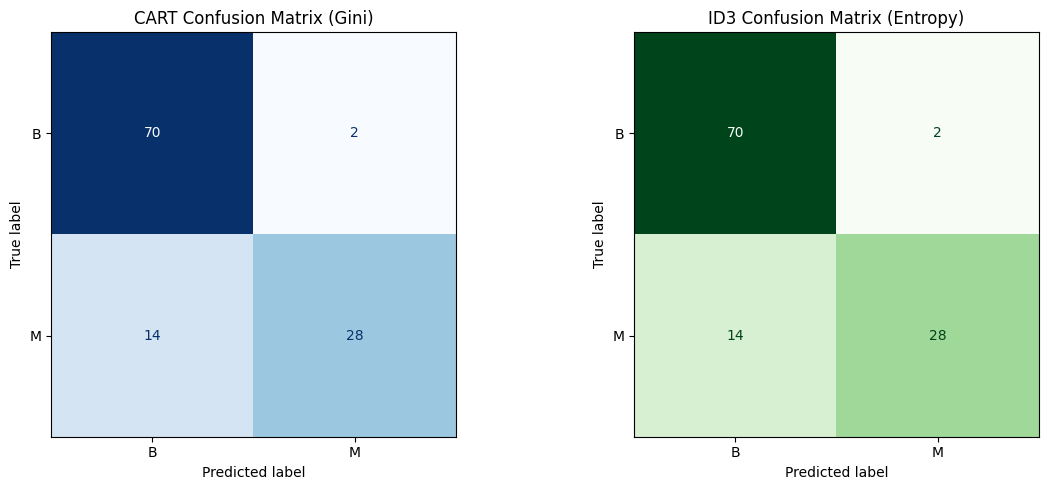

In [12]:
# Cell 12: Confusion Matrix Heatmap - CART vs ID3

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

cart_cm = confusion_matrix(y_test, cart_pred)
id3_cm = confusion_matrix(y_test, id3_pred)

ConfusionMatrixDisplay(
    confusion_matrix=cart_cm,
    display_labels=label_encoder.classes_
).plot(ax=axes[0], cmap="Blues", colorbar=False)

axes[0].set_title("CART Confusion Matrix (Gini)")

ConfusionMatrixDisplay(
    confusion_matrix=id3_cm,
    display_labels=label_encoder.classes_
).plot(ax=axes[1], cmap="Greens", colorbar=False)

axes[1].set_title("ID3 Confusion Matrix (Entropy)")

plt.tight_layout()
plt.show()

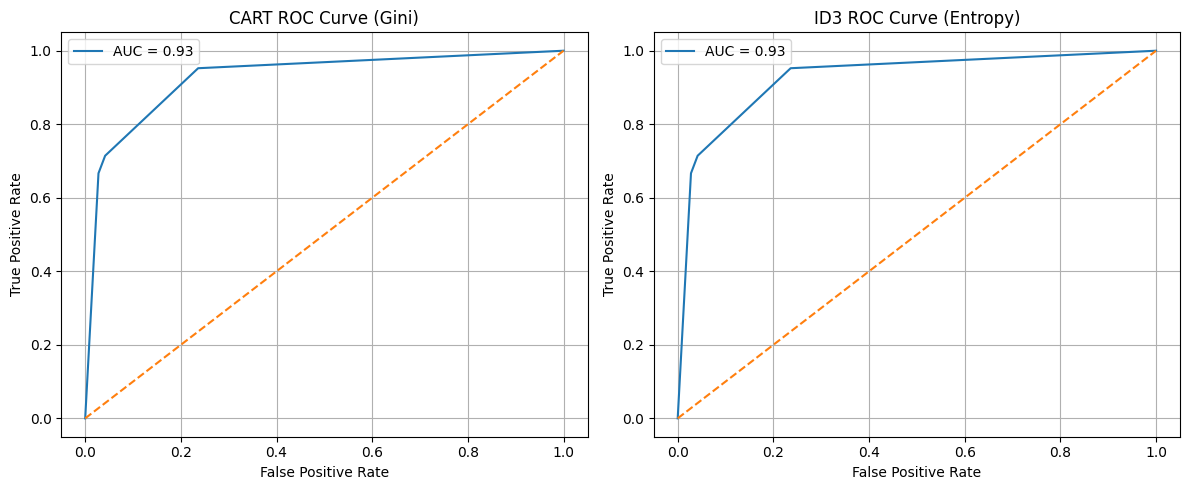

In [13]:
# Cell 13: ROC Curve Plot - CART vs ID3

cart_fpr, cart_tpr, _ = roc_curve(y_test, cart_prob)
id3_fpr, id3_tpr, _ = roc_curve(y_test, id3_prob)

cart_auc = roc_auc_score(y_test, cart_prob)
id3_auc = roc_auc_score(y_test, id3_prob)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(cart_fpr, cart_tpr, label=f"AUC = {cart_auc:.2f}")
axes[0].plot([0, 1], [0, 1], linestyle="--")
axes[0].set_title("CART ROC Curve (Gini)")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(id3_fpr, id3_tpr, label=f"AUC = {id3_auc:.2f}")
axes[1].plot([0, 1], [0, 1], linestyle="--")
axes[1].set_title("ID3 ROC Curve (Entropy)")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

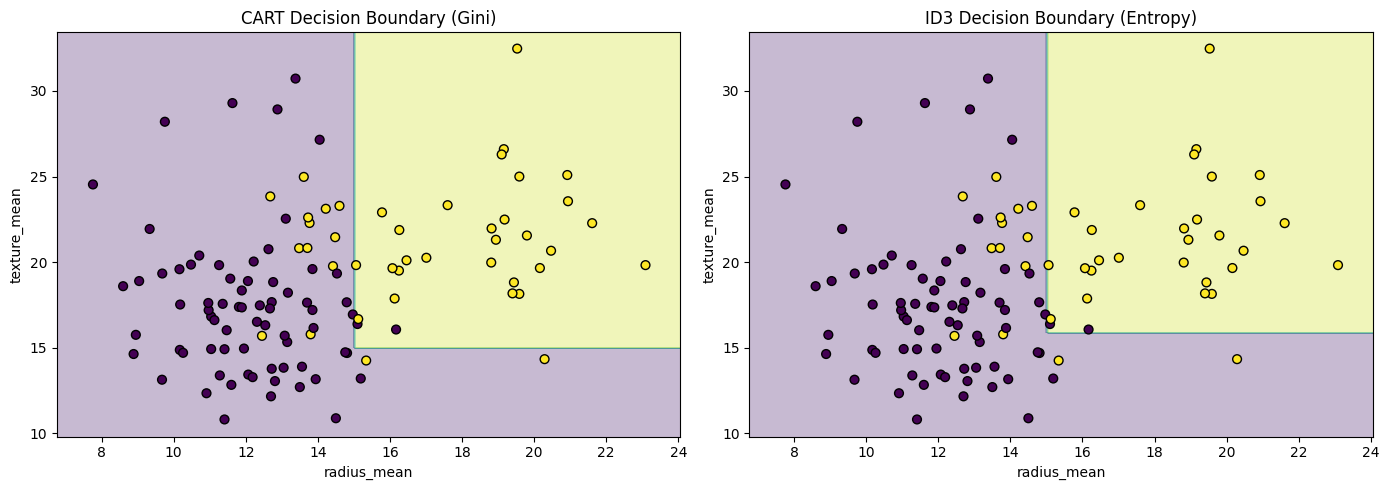

In [14]:
# Cell 14: Decision Boundary Plot - CART vs ID3

def plot_decision_boundary(model, X, y, ax, title):
    x_min, x_max = X.iloc[:, 0].min() - 1, X.iloc[:, 0].max() + 1
    y_min, y_max = X.iloc[:, 1].min() - 1, X.iloc[:, 1].max() + 1

    xx, yy = np.meshgrid(
        np.arange(x_min, x_max, 0.1),
        np.arange(y_min, y_max, 0.1)
    )

    grid_points = pd.DataFrame(
        np.c_[xx.ravel(), yy.ravel()],
        columns=X.columns
    )

    Z = model.predict(grid_points)
    Z = Z.reshape(xx.shape)

    ax.contourf(xx, yy, Z, alpha=0.3)
    ax.scatter(X.iloc[:, 0], X.iloc[:, 1], c=y, edgecolor="k", s=40)
    ax.set_title(title)
    ax.set_xlabel(X.columns[0])
    ax.set_ylabel(X.columns[1])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

plot_decision_boundary(
    best_cart,
    X_test,
    y_test,
    axes[0],
    "CART Decision Boundary (Gini)"
)

plot_decision_boundary(
    best_id3,
    X_test,
    y_test,
    axes[1],
    "ID3 Decision Boundary (Entropy)"
)

plt.tight_layout()
plt.show()

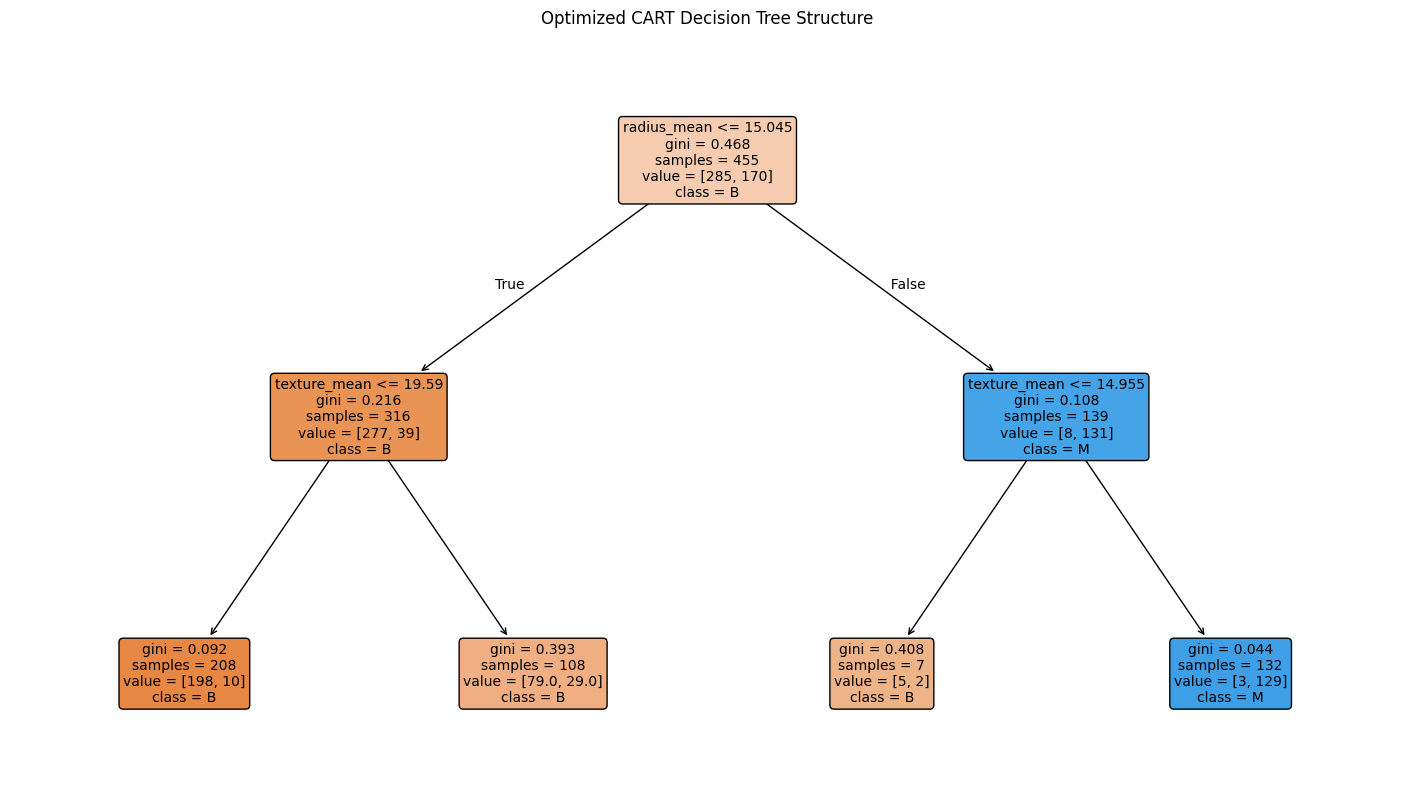

In [15]:
# Cell 15: Decision Tree Structure Visualization

plt.figure(figsize=(18, 10))

plot_tree(
    best_cart,
    feature_names=X.columns,
    class_names=label_encoder.classes_,
    filled=True,
    rounded=True,
    fontsize=10
)

plt.title("Optimized CART Decision Tree Structure")
plt.show()

# Cell 16: Final Comparison Summary

This project compared two Decision Tree models: CART using the Gini criterion and ID3 using the Entropy criterion. Both models were tuned using Cross-Validation with max_depth and min_samples_split. Based on the evaluation metrics, confusion matrix, ROC curve, and decision boundary plots, the better model can be selected by comparing Accuracy, Precision, Recall, F1 Score, and AUC.

In [16]:
# Cell 17: Final Confirmation

print("Decision Tree Assignment Completed Successfully.")
print("Models compared:")
print("1. CART using Gini")
print("2. ID3 using Entropy")
print("\nOutputs generated:")
print("1. Decision Boundary Plot - 2x1 Comparison")
print("2. Confusion Matrix Heatmap - 2x1 Comparison")
print("3. ROC Curve Plot - 2x1 Comparison")
print("4. Evaluation Metrics Bar Chart")
print("5. Decision Tree Structure Visualization")

Decision Tree Assignment Completed Successfully.
Models compared:
1. CART using Gini
2. ID3 using Entropy

Outputs generated:
1. Decision Boundary Plot - 2x1 Comparison
2. Confusion Matrix Heatmap - 2x1 Comparison
3. ROC Curve Plot - 2x1 Comparison
4. Evaluation Metrics Bar Chart
5. Decision Tree Structure Visualization
